# LSZ Spectroscopy — main driver notebook

All physics, Fourier analysis, spectrum reconstruction, and state-vector validation live in `src/`. This notebook only wires them together.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import qutip as qt

sys.path.append('/Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/lsz_spectroscopy/src')

from lsz_experiment import LSZ_experiment, run_experiment_sweep, set_global_seed
from diagnostics import run_full_diagnostics

## Parameters

In [13]:
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

In [ ]:
epsilon = 1
max_wait_time =100
ramp_time = 1
n_steps = 201
dt = 0.01
r_noise = False
w_noise = False

# 2 qubit example (GHz)
# local_z_list = np.array([2.1, 1.1])
# local_x_list = np.array([0., 0.])
# zz_terms = np.array([0.35])
# t1_rates = [0.018, 0.012]
# t2_rates = [0.01, 0.015]
# up_assymetry_coefficients = [1,1]
# down_assymetry_coefficients = [1,1]
# n_qubits = len(local_z_list)
# psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1)]*n_qubits)


#Bell state example
local_z_list = np.array([1,1])
local_x_list = np.array([1, 1])
zz_terms = np.array([1])
t1_rates = [0., 0.]
t2_rates = [0., 0.]
up_assymetry_coefficients = [1, 1]
down_assymetry_coefficients = [1, 1]


average_ramp_error = 0.0
average_wait_error = 0.0 
noise_seed = 0             

# Seed the module-level RNG once
set_global_seed(noise_seed)

n_qubits = len(local_z_list)

#Superposition Singlet
# psi_p= 1/np.sqrt(2)*qt.tensor([ket1,ket0]) + 1/np.sqrt(2)*qt.tensor([ket0,ket1])
# psi_m = 1/np.sqrt(2)*qt.tensor([ket1,ket0]) - 1/np.sqrt(2)*qt.tensor([ket0,ket1])
# psi0 = 1/2*(qt.tensor([ket0,ket0]) + psi_p + psi_m + qt.tensor([ket1,ket1]))

# psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1),1/np.sqrt(2)*(ket0 + ket1)])

psi0 = qt.tensor([1/np.sqrt(2)*(ket0 - ket1)]*n_qubits)


#GHZ state example
# local_z_list = np.array([0.1, -0.1])
# local_x_list = np.array([0.1, 0.1])
# zz_terms = np.array([-1])
# t1_rates = [0.018, 0.012]
# t2_rates = [0.01, 0.012]
# up_assymetry_coefficients = [1,100]
# down_assymetry_coefficients = [1,1]
# n_qubits = len(local_z_list)
# psi0 = qt.tensor([1/np.sqrt(2)*(ket0 + ket1)]*n_qubits)
# psi0 = qt.tensor([ket0, ket0])


#Superposition GHZ
# psi_p= 1/np.sqrt(2)*qt.tensor([ket1,ket1]) + 1/np.sqrt(2)*qt.tensor([ket0,ket0])
# psi_m = 1/np.sqrt(2)*qt.tensor([ket0,ket0]) - 1/np.sqrt(2)*qt.tensor([ket1,ket1])
# psi0 = 1/2*(qt.tensor([ket0,ket1]) + psi_p + psi_m + qt.tensor([ket1,ket0]))


#3 qubit example
# local_z_list = np.array([2.1, 3.05, 1.78])
# zz_terms = np.array([1.22, 0.54, 0.3])

# t1_rates = [0.005, 0.0051, 0.0048]
# t2_rates = [0.01, 0.012, 0.0098]

nqubits = len(local_z_list)
n_sims = int(max_wait_time*10)

tw_l = np.linspace(0, max_wait_time, n_sims)

H_target_dict = {'local_z': local_z_list, 'local_x': local_x_list, 'two_body': zz_terms}

print('Max wait time:', max_wait_time)
print('dt:', dt)
print('Number of simulations:', n_sims)

Max wait time: 100
dt: 0.01
Number of simulations: 1000


## Schedule and spectrum preview

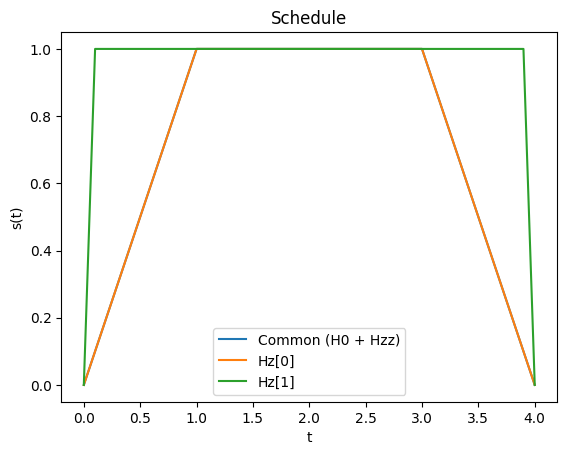

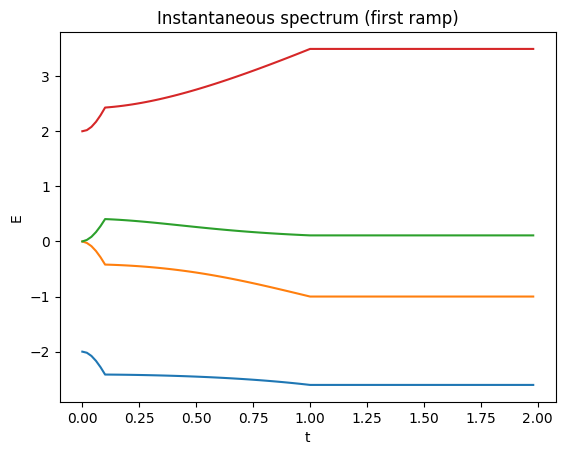

Spectrum at midpoint: [-2.60387547 -1.          0.10991626  3.49395921]

--- True transition frequencies ---
  f[0] = 1.603875
  f[1] = 2.713792
  f[2] = 6.097835
  f[3] = 1.109916
  f[4] = 4.493959
  f[5] = 3.384043

  Min peak separation: 0.493959

--- Eigenvectors at midpoint ---
  v[0]: [-0.186 -0.j  0.5211+0.j  0.5211+0.j -0.6498-0.j]
  v[1]: [-0.    +0.j -0.7071+0.j  0.7071+0.j  0.    +0.j]
  v[2]: [-0.2892+0.j  0.4179+0.j  0.4179+0.j  0.753 +0.j]
  v[3]: [-0.939 +0.j -0.2319+0.j -0.2319+0.j -0.1032+0.j]


In [23]:
preview = LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, 2, dt,
                         up_assymetry_factors=up_assymetry_coefficients,
                         down_assymetry_factors=down_assymetry_coefficients,
                         ramp_error=average_ramp_error,
                         wait_error=average_wait_error)

t_list, common_schedule, hz_schedules = preview.show_schedule(n_steps)
plt.plot(t_list, common_schedule, label='Common (H0 + Hzz)')
for i, hz_s in enumerate(hz_schedules):
    plt.plot(t_list, hz_s, label=f'Hz[{i}]')
plt.xlabel('t'); plt.ylabel('s(t)'); plt.title('Schedule')
plt.legend()
plt.show()

t_list, egvals, egvecs = preview.show_spectrum(n_steps)
midpoint = int(len(t_list)/2)
plt.plot(t_list[0:midpoint], egvals[0:midpoint])
plt.xlabel('t'); plt.ylabel('E'); plt.title('Instantaneous spectrum (first ramp)')
plt.show()

egvals_midpoint = egvals[midpoint]
print('Spectrum at midpoint:', egvals_midpoint)

freqs_true = []
for i, val_i in enumerate(egvals_midpoint[0:-1]):
    for val_j in egvals_midpoint[i+1:]:
     freqs_true.append(abs(val_j - val_i))

print("\n--- True transition frequencies ---")
for i, f in enumerate(freqs_true):
    print(f"  f[{i}] = {f:.6f}")

peak_separations = []
for i, val_i in enumerate(freqs_true[0:-1]):
    for val_j in freqs_true[i+1:]:
     peak_separations.append(abs(val_j - val_i))

print(f"\n  Min peak separation: {min(peak_separations):.6f}")

print("\n--- Eigenvectors at midpoint ---")
vecs = egvecs[midpoint]
for k, vec in enumerate(vecs.T):
    print(f"  v[{k}]: {np.array2string(vec, precision=4, suppress_small=True)}")

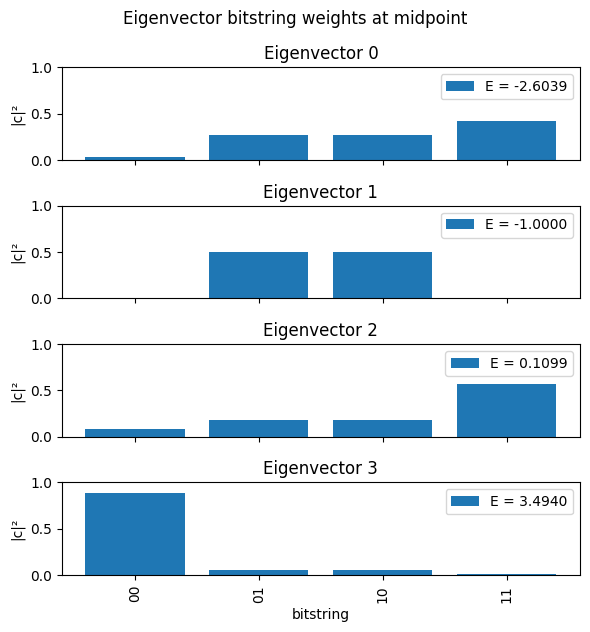

In [24]:
vecs_mid = np.asarray(egvecs[midpoint])
dim = vecs_mid.shape[0]
bitstrings = [format(i, f'0{nqubits}b') for i in range(dim)]
x = np.arange(dim)

fig, axes = plt.subplots(dim, 1, figsize=(max(6, dim), 1.6 * dim), sharex=True)
if dim == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    weights = np.abs(vecs_mid[:, k]) ** 2
    energy = egvals_midpoint[k]
    ax.bar(x, weights, label=f'E = {energy:.4f}')
    ax.set_ylabel(f'|c|²')
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right')
    ax.set_title(f'Eigenvector {k}')
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(bitstrings, rotation=90)
axes[-1].set_xlabel('bitstring')
fig.suptitle('Eigenvector bitstring weights at midpoint')
fig.tight_layout()
plt.show()

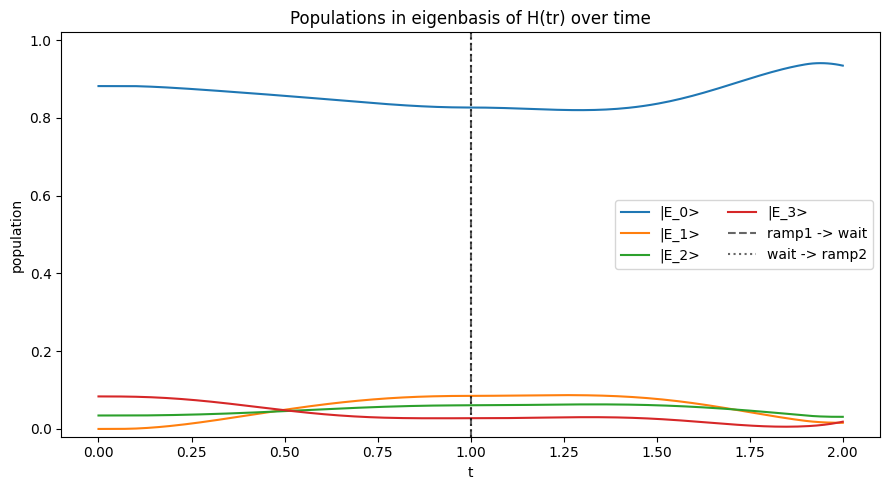

[0.82663876 0.08505446 0.06077208 0.02753469]


In [25]:
sample_wait = 0
evo = LSZ_experiment(nqubits, epsilon, H_target_dict, ramp_time, sample_wait, dt,
                     up_assymetry_factors=up_assymetry_coefficients,
                     down_assymetry_factors=down_assymetry_coefficients,
                     initial_state=psi0,
                     ramp_error=average_ramp_error,
                     wait_error=average_wait_error)
sim_r1, sim_w, sim_r2 = evo.time_evolution()

pops_r1 = evo.calculate_eigenbasis_populations(sim_r1)
pops_w  = evo.calculate_eigenbasis_populations(sim_w)
pops_r2 = evo.calculate_eigenbasis_populations(sim_r2)

t_all = np.concatenate([sim_r1.times, sim_w.times, sim_r2.times])
pops_all = np.concatenate([pops_r1, pops_w, pops_r2], axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
for k in range(pops_all.shape[1]):
    ax.plot(t_all, pops_all[:, k], label=f'|E_{k}>')

ax.axvline(evo.tr,          color='k', linestyle='--', alpha=0.6, label='ramp1 -> wait')
ax.axvline(evo.tr + evo.tw, color='k', linestyle=':',  alpha=0.6, label='wait -> ramp2')

ax.set_xlabel('t')
ax.set_ylabel('population')
ax.set_title('Populations in eigenbasis of H(tr) over time')
ax.set_ylim(-0.02, 1.02)
ax.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()

print(pops_r1[-1])

## Run the experiment sweep

In [26]:
# Re-seed right before the sweep so the noise realization is reproducible
# regardless of whether the preview cells above were re-run.
set_global_seed(noise_seed)

pc_list = run_experiment_sweep(
    nqubits, epsilon, H_target_dict, ramp_time, tw_l, dt,
    up_assym_list=up_assymetry_coefficients,
    down_assym_list=down_assymetry_coefficients,
    r_noise=r_noise, w_noise=w_noise,
    gamma_dec_list=t1_rates, gamma_dep_list=t2_rates, initial_state=psi0,
    ramp_error=average_ramp_error, wait_error=average_wait_error,
)

  [##############################] 100.00%  iter 1000/1000  elapsed   99.9s  ETA   -0.0s


## Full diagnostics

Fourier analysis + global fit + energy-difference matching + turnpike reconstruction + u_m / phi_m recovery + exact-state validation + (optional) dephasing comparison.

[round 0] f=0.255261  A=0.0723  lam=0.0006  phi=5.600
[round 1] f=0.431932  A=0.0503  lam=0.0000  phi=5.193
[round 2] f=0.970508  A=0.0228  lam=0.0000  phi=2.112
[round 3] f=0.176737  A=0.0052  lam=0.0003  phi=5.857
[round 4] f=0.715234  A=0.0024  lam=0.0005  phi=2.787
[round 5] f=0.538719  A=0.0017  lam=0.0000  phi=3.157


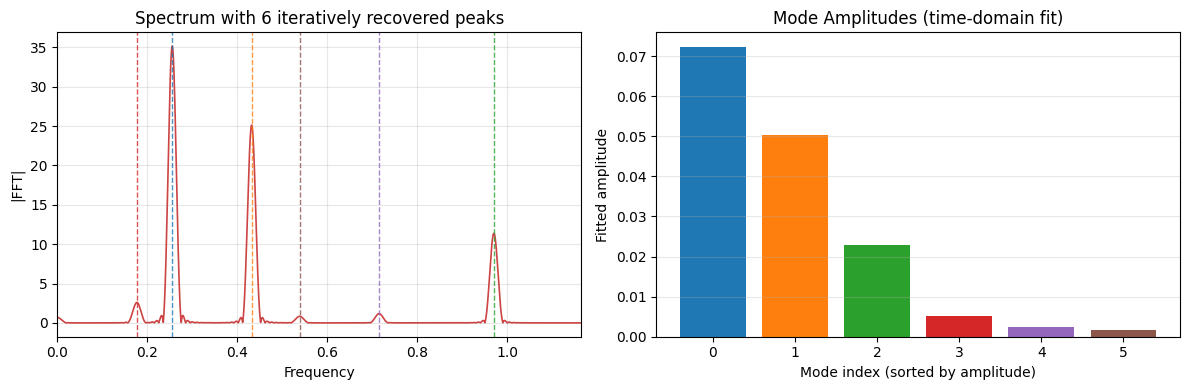


  #       Frequency   Phase (rad)         Amp      Lambda
------------------------------------------------------------
  1        0.255261        5.6004     0.07234     0.00060
  2        0.431932        5.1932     0.05031     0.00000
  3        0.970508        2.1118     0.02280     0.00003
  4        0.176737        5.8572     0.00520     0.00035
  5        0.715234        2.7867     0.00240     0.00049
  6        0.538719        3.1569     0.00166     0.00004


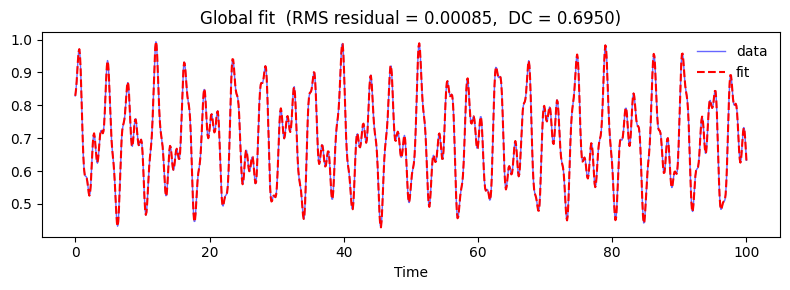

Amplitudes: [0.0703102  0.05023239 0.02276001 0.00517461 0.00234056 0.00167075]
Decay rates: [1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12]
DC (fitted): 0.6950238064548948   DC (mean): 0.6963829529813037

                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        1.603853        1.603875       -0.000022          -0.001%
   2        2.713908        2.713792       +0.000116          +0.004%
   3        6.097882        6.097835       +0.000048          +0.001%
   4        1.110469        1.109916       +0.000552          +0.050%
   5        4.493949        4.493959       -0.000010          -0.000%
   6        3.384874        3.384043       +0.000831          +0.025%
--------------------------------------------------------------------
                        RMS error

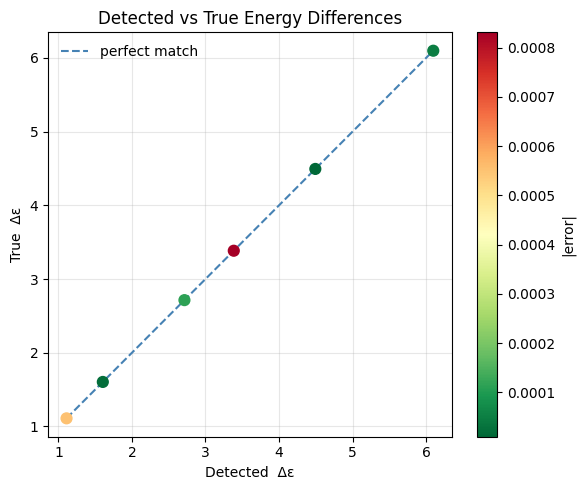

Incomplete Turnpike Solver
  Target levels:        4
  Expected differences: 6
  Observed differences: 6 (100%)

  Trying match threshold = 100% ... no solution at this threshold.
  Trying match threshold = 80% ... no solution at this threshold.
  Trying match threshold = 60% ... no solution at this threshold.
  Trying match threshold = 40% ... found solution explaining 4/6 (67%) of observations.
  Trying match threshold = 20% ... found solution explaining 4/6 (67%) of observations.

  Running greedy solver for comparison...
  Greedy explains 4/6 (67%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(1.6039), np.float64(2.713), np.float64(6.0979)]
    Explains 4/6 observed differences (67%)

                  E0      E1      E2      E3
True:         0.0000  1.6039  2.7138  6.0978
Forward:      0.0000  1.6039  2.7130  6.0979  <-- best
Reversed:     0.0000  3.3849  4.4939  6.0979


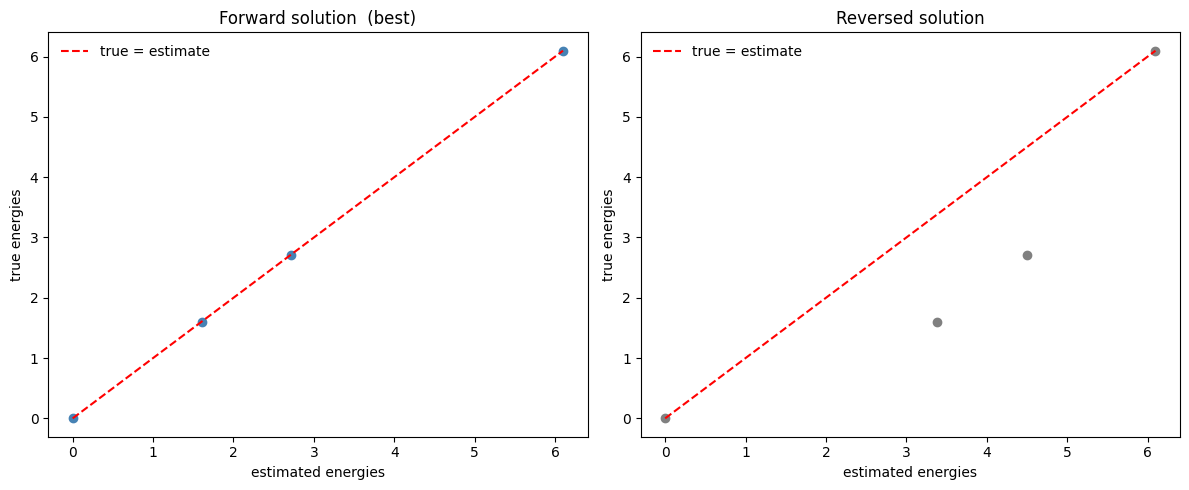

e_m:   [0.     1.6039 2.7139 6.0979]
phi_m: [0.     0.3414 0.545  2.0857]
u_m:   [0.9093 0.2917 0.2465 0.1659]
Exact |u_m|: [0.90919677 0.29164099 0.24651995 0.1659358 ]
Exact phases (mod pi, rel to u_0): [0.         0.34583917 0.54067758 2.08449851]


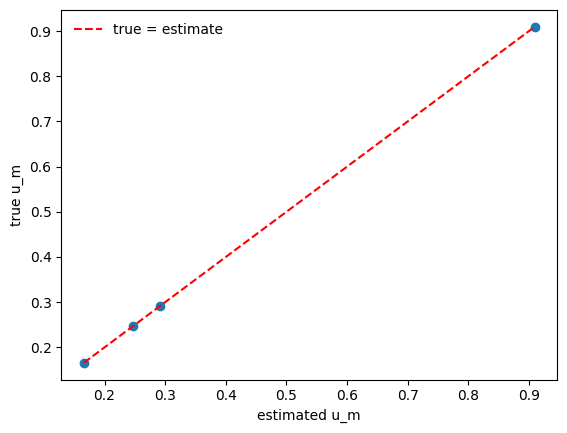

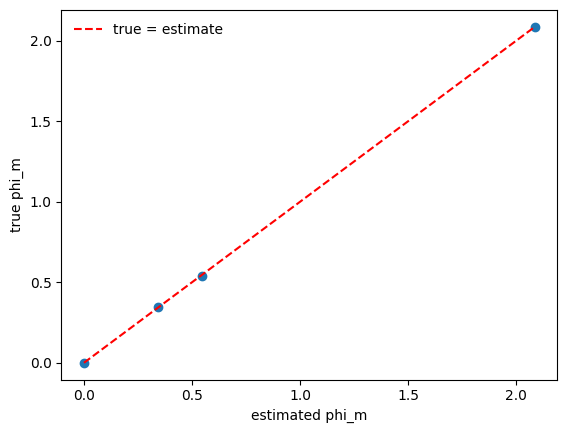

In [27]:
results = run_full_diagnostics(
    pc_list, tw_l, nqubits, epsilon, H_target_dict,
    ramp_time, dt, egvals_midpoint,
    w_noise=w_noise,
    t1_rates=t1_rates if w_noise else None,
    t2_rates=t2_rates if w_noise else None,
    initial_state=psi0,
    up_assym_list=up_assymetry_coefficients,
    down_assym_list=down_assymetry_coefficients,
)

## Joint refinement (warm-start + nonlinear LS)

Stage A estimates the diagonal populations {v_S} from the residual after
subtracting the oscillatory model. Stage B does a joint nonlinear LS fit
of all physical parameters (|u_m|, phi_m, E_m, kappa_phi_q, kappa_T1_q, v_S)
to the time-domain signal, warm-started from the diagnostics output.

The maximum number of function evaluations is exceeded.
Function evaluations 500, initial cost 1.5275e+02, final cost 2.4099e-04, first-order optimality 1.25e-01.
Joint refinement summary
converged: False    n_fev = 500    cost (data) = 2.4099e-04    cost (reg) = 0.0000e+00
message: The maximum number of function evaluations is exceeded.

-- Eigenstate labels (bitstrings) --
  ['11', '10', '11', '00']

-- State-vector moduli |u_m| --
       |u_m|   warm: [0.9096 0.2909 0.246  0.1658]
               refn: [0.9088 0.2918 0.2466 0.1678]
               true: [0.9092 0.2916 0.2465 0.1659]
               |refn-true|: [0.0004 0.0001 0.0001 0.0019]

-- Phases phi_m --
       phi_m   warm: [0.     1.9296 0.5452 2.0847]
               refn: [ 0.      1.2214 -0.5453  1.0566]
               true: [0.     0.3458 0.5407 2.0845]
               |refn-true|: [0.     0.8756 1.086  1.0279]

-- Energies E_m (relative to E_0 = 0) --
         E_m   warm: [0.     1.604  2.714  6.0979]
               refn: [0

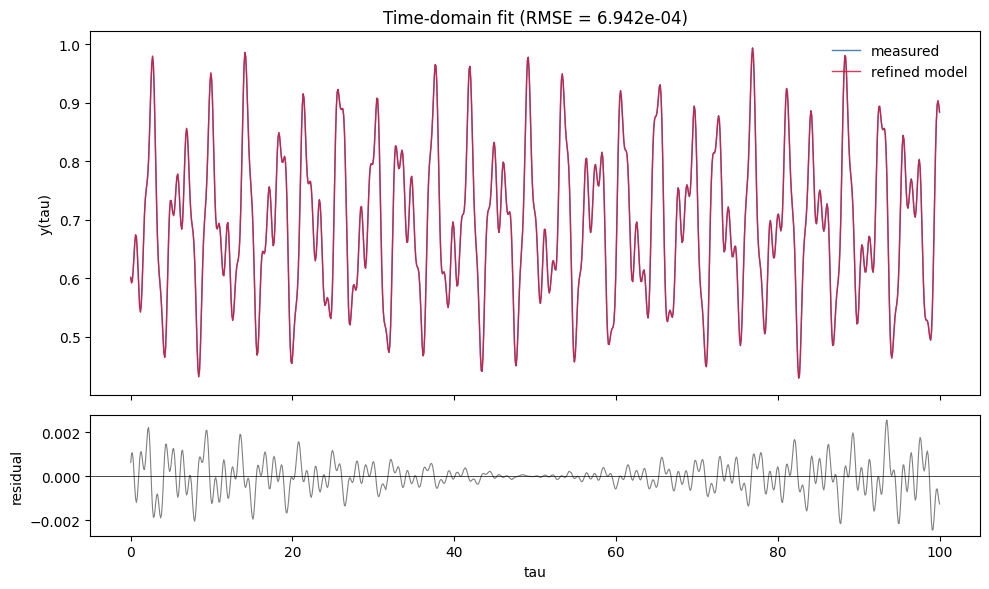

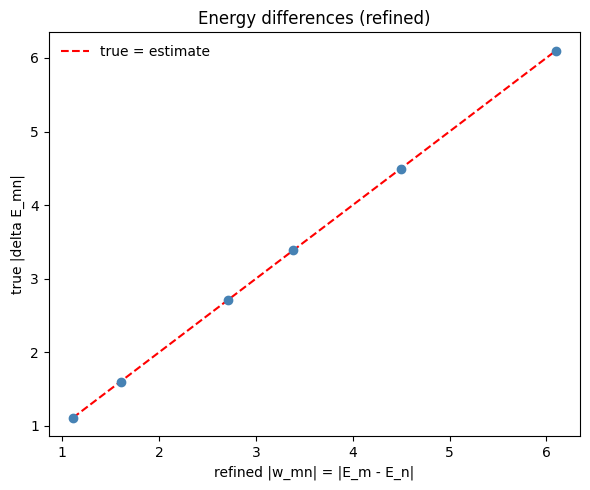

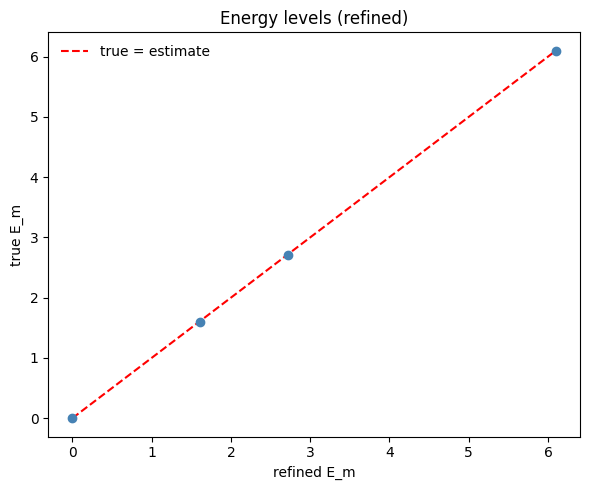

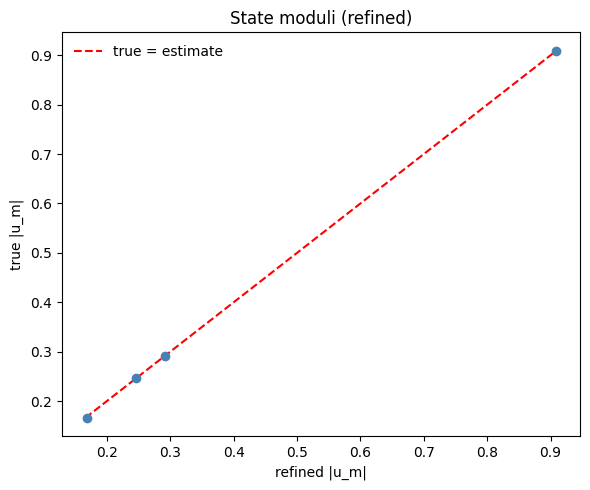

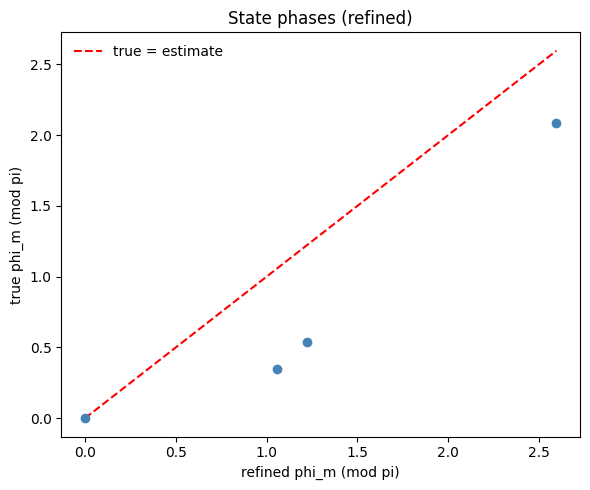

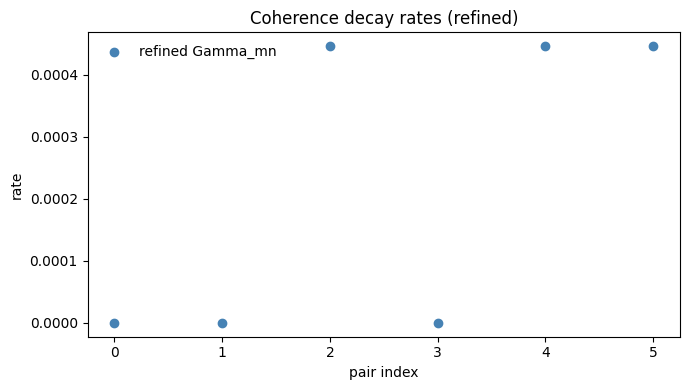

{'rmse': 0.0006942499390819962,
 'y_model': array([0.60129698, 0.5920363 , 0.59573884, 0.61261188, 0.63740774,
        0.66117095, 0.67445397, 0.67083551, 0.64945565, 0.61562847,
        0.57928227, 0.55175969, 0.54210247, 0.55413381, 0.58536608,
        0.62810598, 0.67233965, 0.7093414 , 0.73469336, 0.74962167,
        0.76016996, 0.77451995, 0.79944743, 0.83722396, 0.88412209,
        0.93111   , 0.96653447, 0.97987217, 0.96523806, 0.92341703,
        0.86170297, 0.79160418, 0.72522514, 0.67159544, 0.63422061,
        0.61067908, 0.59434651, 0.57756329, 0.55504842, 0.52628712,
        0.49600629, 0.47255955, 0.46481407, 0.47868625, 0.51460925,
        0.56688467, 0.625192  , 0.67774883, 0.71501493, 0.7326324 ,
        0.73256443, 0.72204052, 0.71070324, 0.70699572, 0.71509822,
        0.73351746, 0.75582923, 0.77328955, 0.77834762, 0.76776137,
        0.74415491, 0.71541742, 0.69212392, 0.68387744, 0.6958712 ,
        0.72690174, 0.76955471, 0.81251491, 0.84419889, 0.85644086,
     

In [20]:
from refinement import run_refinement, print_refinement_summary, plot_refined_diagnostics

refine_results = run_refinement(
    results, tw_l, pc_list,
    reg=None,
    max_nfev=500,
    verbose=1,
    freeze_E=True,
    population_mode="subsets",    # "dc": single scalar baseline like fit_decay_rates. Use "subsets" for the full v_S Markov sector, or "off" to drop it entirely.
    x_scale="auto",          # per-block scaling -> sensible step sizes for rates
    loss="linear",           # match the global fit; switch to "soft_l1" if noise is heavy
    f_scale=1.0,             # transition scale for robust losses (unused for "linear")
    anchor_kappa_weight=0.0, # set > 0 (e.g. 1e3) to pin (kphi, kT1) near NNLS warm-start
    keep_warm_if_worse=True, # safeguard: revert if data cost increases
)

# Build a truth dict (only available because this is a simulator run).
truth = {
    'u_abs': results['u_exact_amplitudes'],
    'phi':   results['u_exact_phases_rel'],
    'kphi':  np.asarray(t2_rates) if w_noise else None,
    'kT1':   np.asarray(t1_rates) if w_noise else None,
}

print_refinement_summary(refine_results, truth=truth)

plot_refined_diagnostics(
    refine_results, results, tw_l, pc_list,
    exact_lambdas=results.get('exact_lambdas'),
)

In [21]:
"""
Forward calculation of coherence decay rates Gamma_{mn} from per-qubit
T1 and T2_phi (pure dephasing) times.

This is the inverse companion to extract_rates.py: given the underlying
per-qubit decoherence parameters, predict what coherence decay rates one
should observe in the LZS signal. Useful for:

  - Validating the structural formula before fitting real data.
  - Generating synthetic test data for the rate-extraction pipeline.
  - Sanity-checking extracted rates by re-predicting and comparing
    to observed Gamma_{mn}.

The formula being implemented is:

    Gamma_{mn} = sum_q [ kappa_phi_q * d_q(m,n)
                        + (1/2) * kappa_T1_q * (e_q(m) + e_q(n)) ]

where, with the convention 0 -> |0> (z=+1), 1 -> |1> (z=-1):

    d_q(m,n) = 1 if qubits m,n disagree on bit q, else 0
    e_q(m)   = 1 if qubit q is excited (|1>) in state m, else 0

    kappa_phi_q = 1 / T2_phi_q   (pure dephasing rate of qubit q)
    kappa_T1_q  = 1 / T1_q       (amplitude damping rate of qubit q)

For a single qubit this reduces to the textbook
    Gamma_{0,1} = 1/(2 T1) + 1/T2_phi.
"""

import numpy as np
from itertools import combinations, product


def enumerate_bitstrings(N_q):
    """
    Enumerate all 2^N_q computational basis states as 0/1 bitstrings.
    Convention: leftmost bit = qubit 1 = most significant.

    Returns: (2^N_q, N_q) array, row m gives the bitstring of state |m>.
    """
    return np.array([[(m >> (N_q - 1 - q)) & 1 for q in range(N_q)]
                     for m in range(2 ** N_q)], dtype=int)


def predict_gamma_rates(T1_list, T2_phi_list, return_breakdown=False):
    """
    Predict coherence decay rates Gamma_{mn} for all pairs of computational
    basis states, given per-qubit T1 and pure-dephasing T2_phi times.

    Parameters
    ----------
    T1_list : array_like of length N_q
        Amplitude damping times for each qubit. Units: time (e.g. microseconds).
        Use np.inf for a qubit with no T1 decay.
    T2_phi_list : array_like of length N_q
        Pure dephasing times for each qubit (NOT total T2 -- this is the
        contribution beyond the T1-induced dephasing). Units: same as T1.
        Use np.inf for a qubit with no pure dephasing.
    return_breakdown : bool
        If True, also return separate dephasing and amplitude-damping
        contributions for diagnostic purposes.

    Returns
    -------
    Gamma : dict {(m, n): rate}
        Total coherence decay rate for each pair m < n.
        Keys are tuples of state indices, values are rates in 1/(time unit).
    breakdown : dict (only if return_breakdown=True)
        {'dephasing': {(m,n): rate}, 'amp_damping': {(m,n): rate}}
    """
    T1 = np.asarray(T1_list, dtype=float)
    T2_phi = np.asarray(T2_phi_list, dtype=float)
    if T1.shape != T2_phi.shape:
        raise ValueError("T1_list and T2_phi_list must have the same length")

    N_q = T1.size
    # Use safe inversion: 1/inf = 0, leaving qubits without that decay channel.
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)
    kappa_phi = np.where(np.isfinite(T2_phi) & (T2_phi > 0), 1.0 / T2_phi, 0.0)

    bitstrings = enumerate_bitstrings(N_q)  # shape (2^N_q, N_q)
    M = bitstrings.shape[0]

    Gamma = {}
    deph = {}
    amp = {}

    for m, n in combinations(range(M), 2):
        bm = bitstrings[m]
        bn = bitstrings[n]

        # Dephasing contribution: rate per qubit where the two states disagree.
        d = (bm != bn).astype(float)
        gamma_phi = float(np.sum(kappa_phi * d))

        # Amplitude damping contribution: rate per qubit, weighted by
        # (excited-in-m) + (excited-in-n), times 1/2.
        e_sum = bm.astype(float) + bn.astype(float)
        gamma_T1 = 0.5 * float(np.sum(kappa_T1 * e_sum))

        Gamma[(m, n)] = gamma_phi + gamma_T1
        deph[(m, n)] = gamma_phi
        amp[(m, n)] = gamma_T1

    if return_breakdown:
        return Gamma, {'dephasing': deph, 'amp_damping': amp}
    return Gamma


def predict_T1_eigenvalues(T1_list):
    """
    Predict the 2^N_q eigenvalues of the population Markov-chain rate matrix W
    under independent amplitude damping. These are the decay rates that
    appear in the zero-frequency Lorentzian fit.

    Each subset S of {1,...,N_q} contributes mu_S = sum_{q in S} kappa_T1_q.

    Parameters
    ----------
    T1_list : array_like of length N_q

    Returns
    -------
    eigenvalues : dict {frozenset(qubit indices): mu_S}
        The empty subset gives mu = 0 (steady state).
    """
    T1 = np.asarray(T1_list, dtype=float)
    N_q = T1.size
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)

    eigenvalues = {}
    for mask in range(2 ** N_q):
        S = frozenset(q for q in range(N_q) if (mask >> q) & 1)
        eigenvalues[S] = float(sum(kappa_T1[q] for q in S))
    return eigenvalues


# -----------------------------------------------------------------------------
# Validation against direct Lindblad simulation
# -----------------------------------------------------------------------------

def lindblad_decay_rates_numeric(T1_list, T2_phi_list):
    """
    Directly evaluate the decay rate of each coherence rho_{mn} under
    independent per-qubit Lindblad dissipators

        L_phi,q = sqrt(kappa_phi_q / 2) * sigma_z[q]   (pure dephasing)
        L_T1,q  = sqrt(kappa_T1_q)      * sigma_-[q]   (amplitude damping)

    With this normalization the dephasing dissipator gives a coherence
    decay rate of kappa_phi_q per disagreeing qubit, matching the
    structural formula above and the textbook single-qubit 1/T2 =
    1/(2 T1) + 1/T2_phi.

    Returns dict {(m,n): rate} computed directly from the Lindbladian.
    """
    T1 = np.asarray(T1_list, dtype=float)
    T2_phi = np.asarray(T2_phi_list, dtype=float)
    N_q = T1.size
    M = 2 ** N_q
    kappa_T1 = np.where(np.isfinite(T1) & (T1 > 0), 1.0 / T1, 0.0)
    kappa_phi = np.where(np.isfinite(T2_phi) & (T2_phi > 0), 1.0 / T2_phi, 0.0)

    bitstrings = enumerate_bitstrings(N_q)
    rates = {}

    for m, n in combinations(range(M), 2):
        bm = bitstrings[m]
        bn = bitstrings[n]
        # Amplitude damping anticommutator on rho_{mn}.
        gamma_amp = 0.5 * np.sum(kappa_T1 * (bm + bn))

        # Pure dephasing on rho_{mn}: (1 - z_m z_n)/2 in {0,1} is the
        # disagreement indicator, and the Lindblad prefactor 1/2 (from the
        # sqrt(kappa_phi/2) normalization) absorbs the textbook factor.
        z_m = 1 - 2 * bm
        z_n = 1 - 2 * bn
        gamma_deph = 0.5 * np.sum(kappa_phi * (1 - z_m * z_n))

        rates[(m, n)] = float(gamma_amp + gamma_deph)
    return rates


# -----------------------------------------------------------------------------
# Self-test / demonstration
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    # # Test parameters: 3 qubits with distinct T1 and T2_phi.
    # T1_list = [10.0, 8.0, 12.0]              # microseconds
    # T2_phi_list = [3.0, 5.0, 4.0]            # microseconds (pure dephasing)
    T1_list = [120, 150]
    T2_phi_list = [110, 100]
    N_q = len(T1_list)

    print(f"Test case: N_q = {N_q}")
    print(f"  T1 (us)     = {T1_list}")
    print(f"  T2_phi (us) = {T2_phi_list}")
    print(f"  kappa_T1   (1/us) = {[1/t for t in T1_list]}")
    print(f"  kappa_phi  (1/us) = {[1/t for t in T2_phi_list]}")
    print()

    # Predict Gamma rates from the structural formula
    Gamma, parts = predict_gamma_rates(T1_list, T2_phi_list,
                                        return_breakdown=True)

    # Cross-check against direct Lindblad evaluation
    Gamma_numeric = lindblad_decay_rates_numeric(T1_list, T2_phi_list)

    bitstrings = enumerate_bitstrings(N_q)
    state_labels = ["".join(str(b) for b in bitstrings[m])
                    for m in range(2**N_q)]

    print("Predicted Gamma_{m,n} rates (formula vs. direct Lindblad):")
    print(f"{'(m,n)':<10} {'states':<14} {'deph':<10} {'amp':<10} "
          f"{'total':<10} {'numeric':<10} {'diff':<10}")
    print("-" * 80)
    max_diff = 0.0
    for (m, n), g in Gamma.items():
        g_num = Gamma_numeric[(m, n)]
        diff = abs(g - g_num)
        max_diff = max(max_diff, diff)
        label = f"|{state_labels[m]}>,|{state_labels[n]}>"
        print(f"({m},{n}){'':<5} {label:<14} "
              f"{parts['dephasing'][(m,n)]:<10.4f} "
              f"{parts['amp_damping'][(m,n)]:<10.4f} "
              f"{g:<10.4f} {g_num:<10.4f} {diff:<10.2e}")

    print(f"\nMax discrepancy formula vs. direct Lindblad: {max_diff:.2e}")
    if max_diff < 1e-10:
        print("Formula validated against direct Lindblad evaluation.")
    else:
        print("WARNING: discrepancy detected -- formula may be miscoded.")

    # Also report the population-sector eigenvalues
    print("\nMarkov-chain eigenvalues mu_S (zero-peak Lorentzian widths):")
    eigvals = predict_T1_eigenvalues(T1_list)
    for S, mu in sorted(eigvals.items(), key=lambda kv: kv[1]):
        S_str = "{" + ",".join(f"q{q+1}" for q in sorted(S)) + "}" if S else "{}"
        print(f"  S = {S_str:<20}  mu_S = {mu:.4f} 1/us")

    # Sanity check: a single qubit's coherence between |0> and |1> should
    # decay at the textbook rate 1/T2 = 1/(2 T1) + 1/T2_phi.
    print("\nSingle-qubit consistency check (qubit 1 isolated):")
    Gamma_q1, _ = predict_gamma_rates([T1_list[0]], [T2_phi_list[0]],
                                       return_breakdown=True)
    g_pred = Gamma_q1[(0, 1)]
    g_textbook = 1 / (2 * T1_list[0]) + 1 / T2_phi_list[0]
    print(f"  Predicted Gamma_{{0,1}} = {g_pred:.4f} 1/us")
    print(f"  Textbook 1/(2T1)+1/T2phi = {g_textbook:.4f} 1/us")
    print(f"  Match: {abs(g_pred - g_textbook) < 1e-12}")

Test case: N_q = 2
  T1 (us)     = [120, 150]
  T2_phi (us) = [110, 100]
  kappa_T1   (1/us) = [0.008333333333333333, 0.006666666666666667]
  kappa_phi  (1/us) = [0.00909090909090909, 0.01]

Predicted Gamma_{m,n} rates (formula vs. direct Lindblad):
(m,n)      states         deph       amp        total      numeric    diff      
--------------------------------------------------------------------------------
(0,1)      |00>,|01>      0.0100     0.0033     0.0133     0.0133     0.00e+00  
(0,2)      |00>,|10>      0.0091     0.0042     0.0133     0.0133     0.00e+00  
(0,3)      |00>,|11>      0.0191     0.0075     0.0266     0.0266     0.00e+00  
(1,2)      |01>,|10>      0.0191     0.0075     0.0266     0.0266     0.00e+00  
(1,3)      |01>,|11>      0.0091     0.0108     0.0199     0.0199     0.00e+00  
(2,3)      |10>,|11>      0.0100     0.0117     0.0217     0.0217     0.00e+00  

Max discrepancy formula vs. direct Lindblad: 0.00e+00
Formula validated against direct Lindblad evalu